# WGAN Simulation

## Warning before starting:

Please make sure that you run this notebook with a GPU (click on "RunTime" and "Change your RunTime type").

## 1.- Goals of this notebook

* Understand the concept of a Generative Adversarial Neural Network
* Train a GAN
* Visualize the loss functions as a function of the number of epochs
* Produce synthetic datasets coherent with the LGAD models in the previous exercise

Please download the libraries in order to start.

In [ ]:
!rm -rf InstrumentationSchool/
!git clone https://github.com/parbol/InstrumentationSchool.git
import sys
sys.path.append('/content/InstrumentationSchool')


Cloning into 'InstrumentationSchool'...
remote: Enumerating objects: 530, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 530 (delta 24), reused 64 (delta 16), pack-reused 445 (from 1)
Receiving objects: 100% (530/530), 211.74 KiB | 1.74 MiB/s, done.
Resolving deltas: 100% (221/221), done.


## 2.- Download the data

In the previous exercise you produced a couple of datasets with 2K events. In this exercise we will use some larger datasets. To speed up the process I have already generated these datasets for you, so you just need to download them.

In [ ]:
##### Getting the data
import urllib.request

urllib.request.urlretrieve('https://nextcloud.ifca.es/index.php/s/PfBwMTrjpBkbzTr/download', 'model1.parquet')
urllib.request.urlretrieve('https://nextcloud.ifca.es/index.php/s/7H3Q4iPWPo2Wpsx/download', 'model2.parquet')


print("Data downloaded successfully")

Data downloaded successfully


## 3.- Imports needed by the program

This program makes use of 4 modules:

* Discriminator: This module implements the discriminator of our GAN model.
* Generator: This module implements the generator of our GAN model.
* numpy: This is the standard python package for numerical calculations.
* matplotlib: This is the standard python package for plotting data.
* pandas: This is one of the most popular packages to handle datasets.
* pytorch: This is one of the most popular ML packages.
* StandardScaler: A module to re-scale our data so the features are better conditioned for the learning process.


In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from WGANForLGADSimulation.src.Generator import Generator
from WGANForLGADSimulation.src.Discriminator import Discriminator

seed = 24412345
np.random.seed(seed)
torch.manual_seed(seed)

## 3.- Reading the data into pytorch tensors

In order to start the process we need to read the datasets into pytorch tensors.

In [ ]:
# First of all we make sure we use the GPU
cuda = True if torch.cuda.is_available() else False # GPU Setting
device = 'cuda'
if not cuda:
  device = 'cpu'

print('Device is', device)

# We read the data using pandas
filename = 'model2.parquet'
data = pd.read_parquet(filename).to_numpy()

# We apply the StandardScaler to the data
scaler = StandardScaler()
data = scaler.fit_transform(data)

# We convert the scaled data into a pytorch tensor
tensordata = torch.tensor(data, dtype=torch.float32, device=device)

# Size of the batch
batch_size = 1024

# We create a loader
loader = torch.utils.data.DataLoader(dataset=tensordata, batch_size = batch_size, shuffle=True)

Device is cuda


# 4.- Some questions before your continue (Please edit this cell and add your answers)

Q. What is the role of the StandardScaler? Why is it important?

A.

Q. What is the role of the loader?

A.

Q. What is the batch_size?

A.



## 5.- Creating the models and the optimizers

In this block you will create:

* **The models**: the generator and the discriminator.
* **The optimizers** for each of the models.

In the code you will find a list of hyperparameters for the model. Make sure that you understand the meaning of each of them. Please inspect the models in the repository you downloaded and make sure you understand what they do.

In [ ]:
####################Parameters######################
#dimensions for the latent_space
latent_dim = 12
#conditional variables: p, phi and t
conditional_dim = 3
#output variables: toa, tot
output_dim = 2
#Learning rate
lr = 0.0005

#The models
generator = Generator(latent_dim=latent_dim, conditional_dim=conditional_dim, output_dim=output_dim)
discriminator = Discriminator(conditional_dim=conditional_dim, output_dim=output_dim)
if cuda:
  generator.cuda()
  discriminator.cuda()

#The optimizers
generator_optimizer = torch.optim.Adam(generator.parameters(), lr=lr)
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=lr)


## 6.- Some questions before your continue (Please edit this cell and add your answers)

Q. What is the latent space?

A.

Q. Why the number of conditional dimensios is 3 and the output is 2?

A.

Q. What is the learning rate?

A.

## 7.- Running the actual minimization

The next block handles the real training of the models. PyTorch allows to have a relatively high low-level control of the ML workflows, so in this process you will see that actually 2 minimizations are taking place at the same time. One concerns only the discriminator while the other involves the two of them. The number of steps for the traning of each is also a potential hyperparameter of the system. Make sure you understand well all the steps.

In [ ]:

####################Parameters######################
#Number of epochs
n_epochs = 50
#N steps generation
nstepsgen = 1
#N steps discriminator
nstepsdis = 5
####################Parameters######################


# These lists will be used to store the loss and epochs
epochs = []
loss_disc = []
loss_gen = []

for epoch in range(n_epochs):
  numericLossDiscriminator = 0
  numericLossGenerator = 0
  counterDiscriminator = 0
  counterGenerator = 0
  for i, x in enumerate(loader):
    generatorInput = x[:,1:4]
    realEvents = x[:, 1:6]
    #Running nstepgdis times the discriminator
    for istep in range(nstepsdis):
      discriminator_optimizer.zero_grad()
      z_ = torch.tensor(np.random.normal(0, 1, (generatorInput.shape[0],latent_dim)), dtype=torch.float32, device=device)
      z = torch.cat((z_, generatorInput), 1)
      fakeEvents_ = generator(z)
      fakeEvents = torch.cat((generatorInput, fakeEvents_), 1)
      fakeEventCat = discriminator(fakeEvents.detach())
      realEventCat = discriminator(realEvents)
      f_loss = torch.mean(fakeEventCat) - torch.mean(realEventCat)
      f_loss.backward()
      discriminator_optimizer.step()
      d_l = f_loss.item()
      numericLossDiscriminator = numericLossDiscriminator + d_l
      counterDiscriminator = counterDiscriminator + 1
    #Running nstepgens times the generator
    for istep in range(nstepsgen):
      generator_optimizer.zero_grad()
      z_ = torch.tensor(np.random.normal(0, 1, (generatorInput.shape[0],latent_dim)), dtype=torch.float32, device=device)
      z = torch.cat((z_, generatorInput), 1)
      fakeEvents_ = generator(z)
      fakeEvents = torch.cat((generatorInput, fakeEvents_), 1)
      fakeEventCat = discriminator(fakeEvents)
      g_loss = -torch.mean(fakeEventCat)
      g_loss.backward()
      generator_optimizer.step()
      numericLossGenerator = numericLossGenerator + g_loss.item()
      counterGenerator = counterGenerator + 1
  numericLossGenerator = numericLossGenerator / counterGenerator
  numericLossDiscriminator = numericLossDiscriminator / counterDiscriminator
  print('Epoch:', epoch, 'Generator loss:', numericLossGenerator/counterGenerator, 'Discriminator loss:', numericLossDiscriminator/counterDiscriminator)
  epochs.append(epoch)
  loss_gen.append(numericLossGenerator)
  loss_disc.append(numericLossDiscriminator)

torch.save(generator, 'generator.pt')
torch.save(discriminator, 'discriminator.pt')


Epoch: 0 Generator loss: 0.5234547142845966 Discriminator loss: -1.7188847245776742
Epoch: 1 Generator loss: 2.3525888675235938 Discriminator loss: -7.179958459424095
Epoch: 2 Generator loss: 5.611781337753639 Discriminator loss: -17.10250910757022
Epoch: 3 Generator loss: 9.362353122713783 Discriminator loss: -39.328170715746786
Epoch: 4 Generator loss: 12.392009916643586 Discriminator loss: -58.54723509120226
Epoch: 5 Generator loss: 17.785542276170517 Discriminator loss: -80.69650082565443
Epoch: 6 Generator loss: 26.03615902619209 Discriminator loss: -112.79134884803736
Epoch: 7 Generator loss: 29.784122549276734 Discriminator loss: -156.5612818505704
Epoch: 8 Generator loss: 36.083265514705325 Discriminator loss: -188.41577211918275
Epoch: 9 Generator loss: 42.99783347915774 Discriminator loss: -213.71672369106008
Epoch: 10 Generator loss: 49.5639849526588 Discriminator loss: -284.23438245972244
Epoch: 11 Generator loss: 64.3738774908751 Discriminator loss: -346.32907004509156
Epo

## 8.- Visualize the loss functions

Make a plot with the evolution of the discriminator and generator loss functions as a function of the epoch. Take into account that due to the lack of resources you have run very few epochs so do not expect the results to be very good.

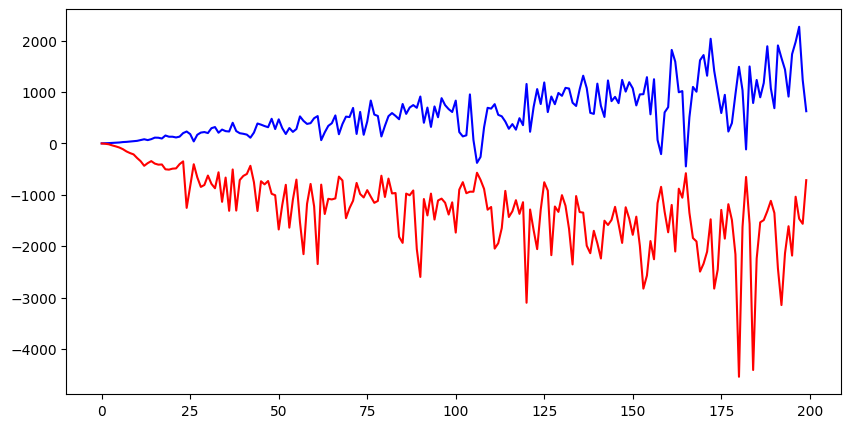

In [ ]:
#Figure
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.asarray(epochs), np.asarray(loss_gen), color='blue')
ax.plot(np.asarray(epochs), np.asarray(loss_disc), color='red')


## 9.- Some questions before your continue (Please edit this cell and add your answers)

Q.- What is the batch size?

A.-

Q.- What is an epoch?

A.-

Q.- Do the loss functions look as you expect?

A.-

Q.- Can you explain in your own words how the generator loss function works?

A.-

Q.- Can you explain in your own words how the discriminator loss function works?



## 10.- Produce a sample with the generator

Write a piece of code that uses the generator to produce a synthetic sample of events. First use the generator that you trained before. The result is probably not spectacular. After that, download a model that was pre-trained during a large number of epochs and do the same.

In [ ]:
model = generator

#urllib.request.urlretrieve('https://nextcloud.ifca.es/index.php/s/WKoHegeB83QjHtM/download', 'generator.pt')
#model = torch.load('generator.pt', weights_only = False, map_location=torch.device(device))

model.eval()

samples = torch.empty((0, data.shape[1]), dtype=torch.float32, device=device)


for i, x in enumerate(loader):

  generatorInput = x[:,1:4]
  z_ = torch.tensor(np.random.normal(0, 1, (generatorInput.shape[0],latent_dim)), dtype=torch.float32, device=device)
  z = torch.cat((z_, generatorInput), 1)
  events = model(z)
  sample = torch.cat((x[:,0:4], events.detach()), 1)
  samples = torch.cat((samples, sample), 0)

data = samples.detach().cpu().numpy()
data = scaler.inverse_transform(data)
dataset = pd.DataFrame({'id': data[:,0], 'p': data[:,1], 'phi': data[:,2], 't': data[:,3], 'toat': data[:,4], 'tot':data[:,5]})
dataset.to_parquet('generatedModel2.parquet')


## 11.- Compare the samples

Write a function to compare the two samples. In particular, compare the toa - t and the tot.

In [ ]:
def makePlots(axs, datanameOriginal, datanameSynthetic):

  data1 = pd.read_parquet(datanameOriginal).to_numpy()
  data2 = pd.read_parquet(datanameSynthetic).to_numpy()


  axs[0].hist(data1[:,4], bins=200, range=(0, 2))
  axs[0].hist(data2[:,4], bins=200, range=(0, 2))
  axs[0].set_xlabel('toa [ns]')

  axs[1].hist(data1[:,5], bins=50, range=(5, 25))
  axs[1].hist(data2[:,5], bins=50, range=(5, 25))
  axs[1].set_xlabel('tot [ns]')



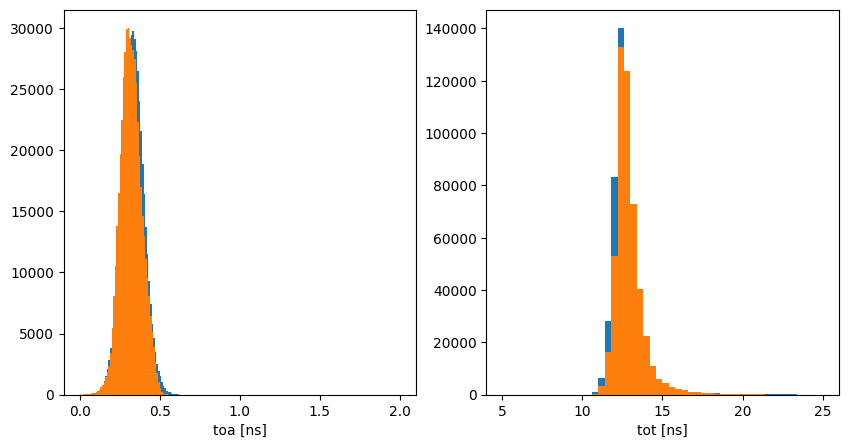

In [ ]:
#Figure
fig, axs = plt.subplots(1, 2, figsize=(10,5))

makePlots(axs, 'model2.parquet', 'generatedModel2.parquet')